Text(0, 0.5, 'Mg')

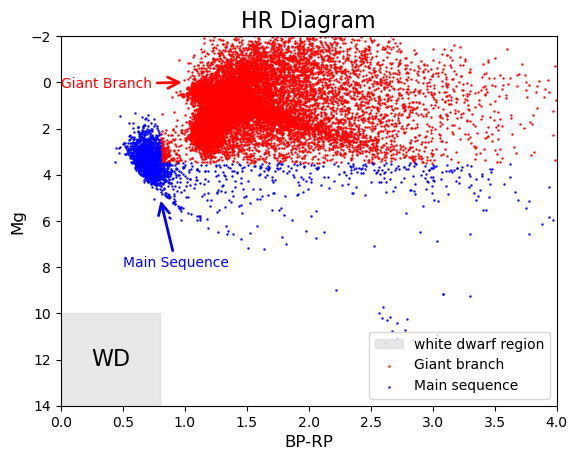

In [67]:
from astropy.io import fits
import numpy as np
import math
import matplotlib.pyplot as plt


# Open the FITS file
hdul = fits.open('APOGEE_stars.fits')

# Access the primary data (in this case, it is a Table)
data = hdul[1].data  # Often, the first extension contains the table
colnames = hdul[1].columns.names # List of the column names

mask = (
    (data['STARFLAG'] == 0) &            #creates mask to filter the data with conditions
    (data['ASPCAPFLAG'] == 0) &
    (data['SNR'] > 10) &
    (data['GAIAEDR3_PARALLAX'] / data['GAIAEDR3_PARALLAX_ERROR'] > 5) &
    (~np.isnan(data['GAIAEDR3_PHOT_G_MEAN_MAG'])) &
    (~np.isnan(data['GAIAEDR3_PHOT_BP_MEAN_MAG'])) &
    (~np.isnan(data['GAIAEDR3_PHOT_RP_MEAN_MAG']))
)

data_clean = data[mask]    #applying the mask

n=len(data_clean)
indices = np.random.choice(n, int(0.1*n), replace=False)      #makes indice list, (length of list, size of sample, replace=False doesnt replace data points once they have been picked)
data_80 = data_clean[indices]  #cleaned data              #COMMENT: 80% made it unseeable so i used 10% instead


parrallax = data_80['GAIAEDR3_PARALLAX']       #defining parrallax and mg
mg=data_80['GAIAEDR3_PHOT_G_MEAN_MAG']


Mg=mg+(5*np.log10(parrallax/1000))+5        #finding absolute magnitude

x_axis = data_80['GAIAEDR3_PHOT_BP_MEAN_MAG'] - data_80['GAIAEDR3_PHOT_RP_MEAN_MAG']         #defining BP-RP


giant_mask = (Mg<3.5)&(x_axis>0.8)


plt.annotate(                                #.annotate( 'string', color, fontsize, xy(head coords), xytext(put text/start))
    'Main Sequence',  
    color='b',
    fontsize=10,
    xy=(0.8, 5),      # arrow head position
    xytext=(0.5, 8),   # arrow start position +text position
    arrowprops=dict(arrowstyle='->', color='b', mutation_scale=20, lw=2))  #mutation scale makes bigger


plt.annotate(                                #.annotate( 'string', color, fontsize, xy(head coords), xytext(put text/start))
    'Giant Branch',  
    color='r',
    fontsize=10,
    xy=(1, 0),      # arrow head position
    xytext=(0, 0.25),   # arrow start position +text position
    arrowprops=dict(arrowstyle='->', color='r', mutation_scale=20, lw=2))  #mutation scale makes bigger


xwd=np.linspace(0,0.8,10)
plt.fill_between(xwd, 10,16,
                 color='lightgrey',
                 alpha=0.5,
                 label='white dwarf region')
plt.text(0.4,12,'WD',fontsize=16, ha='center', va='center')


plt.scatter(x_axis[giant_mask], Mg[giant_mask], color='r', label="Giant branch", s=0.5)          #giant branch
plt.scatter(x_axis[~giant_mask], Mg[~giant_mask], color='b', label='Main sequence', s=0.5) #making scatter plot
plt.legend(loc='lower right')
plt.xlim(0,4)
plt.ylim(14,-2)
plt.title('HR Diagram', size=16)
plt.xlabel('BP-RP', size=12)
plt.ylabel('Mg', size=12)





In [ ]:
STARFLAG == 0
ASPCAPFLAG == 0
SNR > 10
GAIAEDR3_PARALLAX/ GAIAEDR3_PARALLAX_ERROR > 5
GAIAEDR3_PHOT_G_MEAN_MAG is not NaN value
GAIAEDR3_PHOT_BP_MEAN_MAG is not NaN value
GAIAEDR3_PHOT_RP_MEAN_MAG is not NaN value
